# Data Preprocessing

Preprocessing mobility data




In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import datetime

In [2]:
# Data configuration
city = "london"  # {"london", "singapore"}

DICT_YM2DATE = {
    "201903": ["20190304", "20190317"],
    "202003": ["20200302", "20200315"],
    "202103": ["20210301", "20210314"],
    "202203": ["20220307", "20220320"],
    "202502": ["20250210", "20250223"],
}

YEAR = "2021"
MONTH = "03"
RAW_MODE_ROOT = f"/home/jliu/data/Mode/London_historical/London/year={YEAR}/month={MONTH}"
str_study_period = f"{DICT_YM2DATE[f'{YEAR}{MONTH}'][0]}_{DICT_YM2DATE[f'{YEAR}{MONTH}'][1]}"
print(f"Study period: {str_study_period}")

save_root = Path("./mobility_data")
save_root.mkdir(parents=True, exist_ok=True)

Study period: 20210301_20210314


## 0. Get stays from raw mode detection result files

In [3]:
def list_mode_parquet_inputs(raw_mode_root):
    raw_mode_root = Path(raw_mode_root)
    if not raw_mode_root.exists():
        raise FileNotFoundError(f"RAW_MODE_ROOT does not exist: {raw_mode_root}")

    day_dirs = sorted(p for p in raw_mode_root.iterdir() if p.is_dir())
    if day_dirs:
        return day_dirs

    parquet_files = sorted(raw_mode_root.rglob("*.parquet"))
    if not parquet_files:
        raise FileNotFoundError(f"No parquet inputs found under {raw_mode_root}")
    return parquet_files


def stays_from_mode_parquet(raw_mode_root):
    useful_columns = ["user", "time", "segment_id", "lng", "lat", "link_id", "mode"]
    stay_frames = []

    for iter_path in list_mode_parquet_inputs(raw_mode_root):
        print(f"Reading data from {iter_path}...")
        df = pd.read_parquet(iter_path, columns=useful_columns, engine="pyarrow")
        df = df.sort_values(["user", "segment_id", "time"]).reset_index(drop=True)

        # Segment ids are only required to be unique within each day/file.
        df["user_seg_id"] = df["user"] + "_" + df["segment_id"].astype(int).astype(str)
        df_user_seg_id = (
            df[["user_seg_id"]]
            .drop_duplicates()
            .reset_index(drop=True)
            .assign(segment_id=lambda x: x.index + 1)
        )

        df = df.drop(columns=["segment_id"]).merge(df_user_seg_id, on="user_seg_id", how="left")
        stationary_pts = df[df["mode"] == "stationary"]

        iter_df_stay = stationary_pts.groupby("segment_id", as_index=False).agg(
            user_id=("user", "first"),
            start_time=("time", "min"),
            end_time=("time", "max"),
            longitude=("lng", "median"),
            latitude=("lat", "median"),
        )
        stay_frames.append(iter_df_stay)

    if not stay_frames:
        return pd.DataFrame(columns=["user_id", "start_time", "end_time", "longitude", "latitude"])
    df_stays = pd.concat(stay_frames, ignore_index=True)
    # At this point, we can safely drop the segment_id column as it is no longer needed for the subsequent analysis
    df_stays = df_stays.drop(columns='segment_id')    
    return df_stays

In [4]:
df_stays = stays_from_mode_parquet(RAW_MODE_ROOT)
print(f'Number of stays: {len(df_stays):,}')

# Sort by user_id and start_time
df_stays = df_stays.sort_values(by=['user_id', 'start_time']).reset_index(drop=True)

df_stays

Reading data from /home/jliu/data/Mode/London_historical/London/year=2021/month=03/day=01...
Reading data from /home/jliu/data/Mode/London_historical/London/year=2021/month=03/day=02...
Reading data from /home/jliu/data/Mode/London_historical/London/year=2021/month=03/day=03...
Reading data from /home/jliu/data/Mode/London_historical/London/year=2021/month=03/day=04...
Reading data from /home/jliu/data/Mode/London_historical/London/year=2021/month=03/day=05...
Reading data from /home/jliu/data/Mode/London_historical/London/year=2021/month=03/day=06...
Reading data from /home/jliu/data/Mode/London_historical/London/year=2021/month=03/day=07...
Reading data from /home/jliu/data/Mode/London_historical/London/year=2021/month=03/day=08...
Reading data from /home/jliu/data/Mode/London_historical/London/year=2021/month=03/day=09...
Reading data from /home/jliu/data/Mode/London_historical/London/year=2021/month=03/day=10...
Reading data from /home/jliu/data/Mode/London_historical/London/year=2

,user_id,start_time,end_time,longitude,latitude
0,1000015737515804152147553155493395707150667073...,2021-03-01 10:46:49,2021-03-01 13:56:35,-0.458799,51.548626
1,1000015737515804152147553155493395707150667073...,2021-03-02 13:09:48,2021-03-02 14:09:39,-0.463681,51.548683
2,1000015737515804152147553155493395707150667073...,2021-03-02 14:29:51,2021-03-02 14:29:51,-0.458508,51.548672
3,1000015737515804152147553155493395707150667073...,2021-03-03 15:11:35,2021-03-03 23:22:08,-0.458478,51.548687
4,1000015737515804152147553155493395707150667073...,2021-03-04 00:19:25,2021-03-04 18:28:13,-0.458537,51.548691
...,...,...,...,...,...
3950382,9999789611415224216430546013166683984499915978...,2021-03-10 06:19:32,2021-03-10 06:19:34,-0.110881,51.492905
3950383,9999897766855607579697208548163415200254012314...,2021-03-05 09:07:19,2021-03-05 21:49:01,0.012797,51.407864
3950384,9999897766855607579697208548163415200254012314...,2021-03-06 00:49:18,2021-03-06 22:14:18,0.012792,51.407860
3950385,9999897766855607579697208548163415200254012314...,2021-03-07 02:32:44,2021-03-07 21:49:16,0.012787,51.407864


## 1. Basic Cleaning

### 1.1. Make sure the data is within the study area

#### a) London

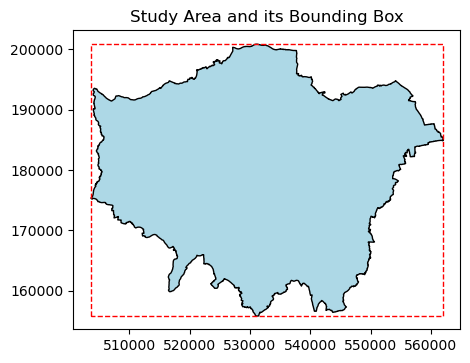

In [5]:
from shapely.geometry import box

# The study area
gdf_study_area = gpd.read_file("~/data/boundary/london/london.shp")
# Get the geodataframe bounding box of the study area
minx, miny, maxx, maxy = gdf_study_area.total_bounds
gdf_study_area_bbox = gpd.GeoDataFrame(geometry=[box(minx, miny, maxx, maxy)], crs=gdf_study_area.crs)

# Plot the study area and its bounding box
fig, ax = plt.subplots(figsize=(5, 5))
gdf_study_area.plot(ax=ax, color='lightblue', edgecolor='black')
gdf_study_area_bbox.plot(ax=ax, color='none', edgecolor='red', linestyle='--')
ax.set_title('Study Area and its Bounding Box')
plt.show()

In [6]:
# filepath = "./mobility_data/stays_london_20250210_20250223.csv.gz"
# # filepath = "mobility_data/stays_london_20250210_20250223_>=2staysperday_aether.csv.gz"
# df_stays = pd.read_csv(filepath)
# df_stays

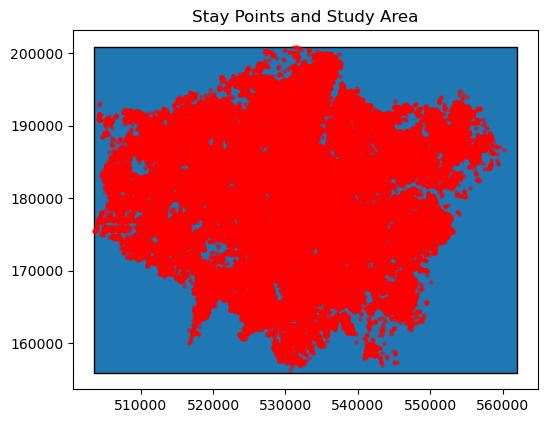

In [6]:
# Plot the stay points and the study area bounding box
gdf_stays = gpd.GeoDataFrame(df_stays, geometry=gpd.points_from_xy(df_stays['longitude'], df_stays['latitude']), crs="EPSG:4326")
gdf_stays = gdf_stays.to_crs(gdf_study_area.crs)  # Ensure the same CRS for plotting
sampled_gdf_stays = gdf_stays.sample(n=100000, random_state=42)  # Sample for better visualization

fig, ax = plt.subplots(figsize=(6, 6))
gdf_study_area_bbox.plot(ax=ax, edgecolor='black')
sampled_gdf_stays.plot(ax=ax, color='red', markersize=5, alpha=0.5)
ax.set_title('Stay Points and Study Area')
plt.show()

In [7]:
# Get the stays within the study area bounding box
gdf_stays_within_bbox = gpd.sjoin(gdf_stays, gdf_study_area_bbox, how='inner', predicate='within').drop(columns='index_right')
gdf_stays_within_bbox = gdf_stays_within_bbox.reset_index(drop=True)
print(f'Number of stays within the study area bounding box: {len(gdf_stays_within_bbox):,}')

gdf_stays_within_bbox

Number of stays within the study area bounding box: 3,950,387


,user_id,start_time,end_time,longitude,latitude,geometry
0,1000015737515804152147553155493395707150667073...,2021-03-01 10:46:49,2021-03-01 13:56:35,-0.458799,51.548626,POINT (506960.553 184428.935)
1,1000015737515804152147553155493395707150667073...,2021-03-02 13:09:48,2021-03-02 14:09:39,-0.463681,51.548683,POINT (506621.922 184428.174)
2,1000015737515804152147553155493395707150667073...,2021-03-02 14:29:51,2021-03-02 14:29:51,-0.458508,51.548672,POINT (506980.622 184434.451)
3,1000015737515804152147553155493395707150667073...,2021-03-03 15:11:35,2021-03-03 23:22:08,-0.458478,51.548687,POINT (506982.667 184436.192)
4,1000015737515804152147553155493395707150667073...,2021-03-04 00:19:25,2021-03-04 18:28:13,-0.458537,51.548691,POINT (506978.566 184436.53)
...,...,...,...,...,...,...
3950382,9999789611415224216430546013166683984499915978...,2021-03-10 06:19:32,2021-03-10 06:19:34,-0.110881,51.492905,POINT (531242.71 178798.169)
3950383,9999897766855607579697208548163415200254012314...,2021-03-05 09:07:19,2021-03-05 21:49:01,0.012797,51.407864,POINT (540087.853 169570.568)
3950384,9999897766855607579697208548163415200254012314...,2021-03-06 00:49:18,2021-03-06 22:14:18,0.012792,51.407860,POINT (540087.503 169570.134)
3950385,9999897766855607579697208548163415200254012314...,2021-03-07 02:32:44,2021-03-07 21:49:16,0.012787,51.407864,POINT (540087.109 169570.548)


#### b) Singapore

In [ ]:
##TODO: Get Singapore boundary

### 1.2. Filter out stays with too short duration

In [8]:
# Copy the stays within the bounding box to a new dataframe for further processing
df_stays = gdf_stays_within_bbox.drop(columns='geometry')  # Drop the geometry column as we won't need it for the subsequent analysis
# Delete the original stays dataframe to free up memory
del gdf_stays
del gdf_stays_within_bbox

In [9]:
# Sort by user_id and start_time
df_stays = df_stays.sort_values(by=['user_id', 'start_time']).reset_index(drop=True)
df_stays

,user_id,start_time,end_time,longitude,latitude
0,1000015737515804152147553155493395707150667073...,2021-03-01 10:46:49,2021-03-01 13:56:35,-0.458799,51.548626
1,1000015737515804152147553155493395707150667073...,2021-03-02 13:09:48,2021-03-02 14:09:39,-0.463681,51.548683
2,1000015737515804152147553155493395707150667073...,2021-03-02 14:29:51,2021-03-02 14:29:51,-0.458508,51.548672
3,1000015737515804152147553155493395707150667073...,2021-03-03 15:11:35,2021-03-03 23:22:08,-0.458478,51.548687
4,1000015737515804152147553155493395707150667073...,2021-03-04 00:19:25,2021-03-04 18:28:13,-0.458537,51.548691
...,...,...,...,...,...
3950382,9999789611415224216430546013166683984499915978...,2021-03-10 06:19:32,2021-03-10 06:19:34,-0.110881,51.492905
3950383,9999897766855607579697208548163415200254012314...,2021-03-05 09:07:19,2021-03-05 21:49:01,0.012797,51.407864
3950384,9999897766855607579697208548163415200254012314...,2021-03-06 00:49:18,2021-03-06 22:14:18,0.012792,51.407860
3950385,9999897766855607579697208548163415200254012314...,2021-03-07 02:32:44,2021-03-07 21:49:16,0.012787,51.407864


In [10]:
# stays_2weeks['segment_id'] =stays_2weeks['segment_id'].astype(int)
print(f'Original number of stays: {len(df_stays):,}')
df_stays['start_time'] = pd.to_datetime(df_stays['start_time'])
df_stays['end_time'] = pd.to_datetime(df_stays['end_time'])
df_stays['date'] = df_stays['start_time'].dt.date
df_stays['total_time_s'] = (df_stays['end_time'] - df_stays['start_time']).dt.total_seconds()
# Filter out stays with total time less than 120 seconds
df_stays = df_stays[df_stays['total_time_s'] >= 120]
df_stays = df_stays.reset_index(drop=True)
print(f'Number of stays after filtering short stays less than 120 seconds: {len(df_stays):,}')

Original number of stays: 3,950,387
Number of stays after filtering short stays less than 120 seconds: 3,217,566


 ### 1.3. Filter out days with too few stays (in other words, too short activity chains)

In [11]:
num_stays_by_userday = df_stays.groupby(['user_id', 'date']).size().reset_index().rename(columns={0: 'num_stays'})
num_stays_by_userday

,user_id,date,num_stays
0,1000015737515804152147553155493395707150667073...,2021-03-01,1
1,1000015737515804152147553155493395707150667073...,2021-03-02,1
2,1000015737515804152147553155493395707150667073...,2021-03-03,1
3,1000015737515804152147553155493395707150667073...,2021-03-04,1
4,1000015737515804152147553155493395707150667073...,2021-03-05,1
...,...,...,...
1194988,9999756146306141484176929575344572752515977750...,2021-03-14,3
1194989,9999897766855607579697208548163415200254012314...,2021-03-05,1
1194990,9999897766855607579697208548163415200254012314...,2021-03-06,1
1194991,9999897766855607579697208548163415200254012314...,2021-03-07,1


In [12]:
num_stays_by_userday['num_stays'].describe()

count    1.194993e+06
mean     2.692540e+00
std      2.343796e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      7.700000e+01
Name: num_stays, dtype: float64

In [13]:
print(f"The proportion of user-days with only 1 stay: {((num_stays_by_userday['num_stays'] == 1).sum() / len(num_stays_by_userday)):.2%}")
print(f"The proportion of user-days with 2 stays: {((num_stays_by_userday['num_stays'] == 2).sum() / len(num_stays_by_userday)):.2%}")
print(f"The proportion of user-days with 3 stays: {((num_stays_by_userday['num_stays'] == 3).sum() / len(num_stays_by_userday)):.2%}")
print(f"The proportion of user-days with 4 stays: {((num_stays_by_userday['num_stays'] == 4).sum() / len(num_stays_by_userday)):.2%}")
print(f"The proportion of user-days with 5 stays: {((num_stays_by_userday['num_stays'] == 5).sum() / len(num_stays_by_userday)):.2%}")

The proportion of user-days with only 1 stay: 42.49%
The proportion of user-days with 2 stays: 16.13%
The proportion of user-days with 3 stays: 16.54%
The proportion of user-days with 4 stays: 9.21%
The proportion of user-days with 5 stays: 5.94%


In [14]:
# Filter out daily activity chains that have less than 2 stays
retained_stays = num_stays_by_userday[num_stays_by_userday['num_stays'] >= 2]
retained_stays.reset_index(drop=True, inplace=True)
retained_stays

,user_id,date,num_stays
0,1000015737515804152147553155493395707150667073...,2021-03-06,2
1,1000015737515804152147553155493395707150667073...,2021-03-07,2
2,1000015737515804152147553155493395707150667073...,2021-03-10,5
3,1000015737515804152147553155493395707150667073...,2021-03-11,3
4,1000015737515804152147553155493395707150667073...,2021-03-14,2
...,...,...,...
687224,9999756146306141484176929575344572752515977750...,2021-03-01,2
687225,9999756146306141484176929575344572752515977750...,2021-03-02,7
687226,9999756146306141484176929575344572752515977750...,2021-03-09,2
687227,9999756146306141484176929575344572752515977750...,2021-03-11,4


In [15]:
df_stays = df_stays.merge(retained_stays[['user_id', 'date']], on=['user_id', 'date'], how='inner')
df_stays = df_stays.sort_values(by=['user_id', 'start_time']).reset_index(drop=True)
df_stays

,user_id,start_time,end_time,longitude,latitude,date,total_time_s
0,1000015737515804152147553155493395707150667073...,2021-03-06 00:04:58,2021-03-06 16:08:55,-0.458548,51.548668,2021-03-06,57837.0
1,1000015737515804152147553155493395707150667073...,2021-03-06 19:33:53,2021-03-06 20:52:11,-0.458592,51.548645,2021-03-06,4698.0
2,1000015737515804152147553155493395707150667073...,2021-03-07 00:09:46,2021-03-07 17:52:17,-0.458510,51.548698,2021-03-07,63751.0
3,1000015737515804152147553155493395707150667073...,2021-03-07 20:49:49,2021-03-07 21:10:50,-0.458652,51.548645,2021-03-07,1261.0
4,1000015737515804152147553155493395707150667073...,2021-03-10 00:04:33,2021-03-10 07:26:44,-0.458493,51.548695,2021-03-10,26531.0
...,...,...,...,...,...,...,...
2709797,9999756146306141484176929575344572752515977750...,2021-03-11 17:26:15,2021-03-11 17:31:03,0.085048,51.603291,2021-03-11,288.0
2709798,9999756146306141484176929575344572752515977750...,2021-03-11 17:58:04,2021-03-11 21:16:38,0.062119,51.586960,2021-03-11,11914.0
2709799,9999756146306141484176929575344572752515977750...,2021-03-14 11:22:07,2021-03-14 14:03:08,0.062120,51.586960,2021-03-14,9661.0
2709800,9999756146306141484176929575344572752515977750...,2021-03-14 14:28:08,2021-03-14 16:56:57,0.064657,51.564606,2021-03-14,8929.0


In [16]:
# clean before saving
df_stays = df_stays.drop(columns=['total_time_s', 'date'])

In [ ]:
# No need to save the stays because later results will be based on this df.
# df_stays.to_csv(f"{save_root}/{city}_{str_study_period}_stays_bbox_min2staysperday.csv.gz", index=False)

In [17]:
valid_user_ids = df_stays['user_id'].unique()
print(f"Number of valid users with at least 2 stays per day: {len(valid_user_ids)}")

Number of valid users with at least 2 stays per day: 104467


In [18]:
df_valid_user_ids = pd.DataFrame({'user_id': valid_user_ids})
df_valid_user_ids.to_csv(f"{save_root}/{city}_{str_study_period}_bbox_min2staysperday_valid_user_ids.csv.gz", index=False)

## 2. Significant Places and Home Location Detection

This module detects significant places for each user based on their stay points, and identifies the home location among the significant places. The output is a dataframe of each user's significant places with a boolean column indicating whether each place is the identified user home location.

The results are saved to `./sigplaces_and_home` for subsequent usage:
- semantic enrichment
- join with df_stays, etc.

### Helper functions

In [19]:
from shapely.geometry import Point
from sklearn.cluster import DBSCAN

def get_night_time_length(row):
    # a function applied to df to get the night time length of each row. nighttime: (22:00, 07:00)
    stay_st, stay_et = row["start_time"], row["end_time"]
    if stay_et.date().day - stay_st.date().day == 0:
        nt1_st, nt1_et = datetime.datetime.combine(stay_st.date(), datetime.time(22, 0, 0)), datetime.datetime.combine(stay_et.date(), datetime.time(23, 59, 59))
        nt2_st, nt2_et = datetime.datetime.combine(stay_st.date(), datetime.time(0, 0, 0)), datetime.datetime.combine(stay_et.date(), datetime.time(7, 0, 0))
        if stay_et > nt1_st:
            nt_length = min(int((stay_et - nt1_st).total_seconds()), int((stay_et - stay_st).total_seconds()))
        elif stay_st < nt2_et:
            nt_length = min(int((nt2_et - stay_st).total_seconds()), int((stay_et - stay_st).total_seconds()))
        else:
            nt_length = 0
    elif stay_et.date().day - stay_st.date().day == 1:
        nt_length = int((stay_et - stay_st).total_seconds())
        if stay_st.time() < datetime.time(7, 0, 0):
            nt_length -= 15*3600
        elif stay_st.time() < datetime.time(22, 0, 0):
            nt_length -= int((datetime.datetime.combine(stay_st.date(), datetime.time(22, 0, 0)) - stay_st).total_seconds())
        else:
            pass
        if stay_et.time() < datetime.time(7, 0, 0):
            pass
        elif stay_et.time() < datetime.time(22, 0, 0):
            nt_length -= int((stay_et - datetime.datetime.combine(stay_et.date(), datetime.time(7, 0, 0))).total_seconds())
        else:
            nt_length -= 15*3600
    else:
        nt_length = 0
    return nt_length

# Get the significant places for each agent by DBSCAN, and calculate the total amount of night time spent in each significant place
def get_significant_places(group):
    # DBSCAN clustering on x, y to get significant places
    X = group["geometry"].apply(lambda x: [x.x, x.y]).to_list()
    clustering = DBSCAN(eps=100, min_samples=2).fit(X)
    group["significant_place"] = clustering.labels_
    # for cluster id = -1, it is noise, and we assign each of them a unique id greater than the max cluster id, incrementally
    max_cluster_id = group["significant_place"].max()
    num_noise_clusters = len(group[group["significant_place"] == -1])
    group.loc[group["significant_place"] == -1, "significant_place"] = range(max_cluster_id+1, max_cluster_id+1+num_noise_clusters)

    # Compute cluster centroids
    cluster_centroids = group.groupby("significant_place")["geometry"].apply(lambda g: Point(np.median([p.x for p in g]), np.median([p.y for p in g])))
    # Map centroid coordinates back to group
    group["cluster_x"] = group["significant_place"].map(lambda cid: cluster_centroids[cid].x)
    group["cluster_y"] = group["significant_place"].map(lambda cid: cluster_centroids[cid].y)

    # group.name contains the current 'user_id' value for this chunk
    # Must reassign user_id in the function, otherwise it will be lost after the groupby-apply-reset_index operation
    group["user_id"] = group.name
    return group

### 2.1 Get processed mobility data

In [20]:
# mobility_data_root = "./mobility_data"

In [21]:
# If df_stays exists in the current namespace, we can skip reading the file again. Otherwise, read the filtered stays from the CSV file.
if 'df_stays' in locals():
    print("df_stays already exists in the current namespace. Skipping reading from CSV.")
else:
    filtered_stay_filename = f"{city}_{str_study_period}_stays_bbox_min2staysperday.csv.gz"
    filtered_file_path = os.path.join(save_root, filtered_stay_filename)
    df_stays = pd.read_csv(filtered_file_path)
df_stays["start_time"] = pd.to_datetime(df_stays["start_time"])
df_stays["end_time"] = pd.to_datetime(df_stays["end_time"])
df_stays['total_time_s'] = (df_stays['end_time'] - df_stays['start_time']).dt.total_seconds()
if df_stays['total_time_s'].isna().sum() > 0:
    print("Warning: There are stays with missing total_time_s values. Please check the data.")
else:
    # ensure total_time_s is of integer type
    df_stays['total_time_s'] = df_stays['total_time_s'].astype(int)

df_stays["nighttime_length"] = df_stays.apply(get_night_time_length, axis=1)

df_stays already exists in the current namespace. Skipping reading from CSV.


In [22]:
gdf_stays = gpd.GeoDataFrame(df_stays, geometry=gpd.points_from_xy(df_stays['longitude'], df_stays['latitude'], crs='EPSG:4326'))
# Convert CRS to London UTM
if city == "london":
    gdf_stays = gdf_stays.to_crs("EPSG:27700")
elif city == "singapore":
    gdf_stays = gdf_stays.to_crs("EPSG:3414")
else:
    raise ValueError(f"Unsupported city: {city}. Supported cities are 'london' and 'singapore'.")


# Option 1:
# gdf_stay_sp = gdf_stays.groupby("user_id").apply(get_significant_places).reset_index().drop(columns='level_1')

# # Option 2:
# gdf_stay_sp = (
#     gdf_stays
#     .groupby("user_id", group_keys=True) # 1. Keep the group key in the index
#     .apply(get_significant_places, include_groups=False) # See note below
#     .reset_index(level=0) # 2. Move 'user_id' from index to column
#     .reset_index(drop=True) # 3. Flatten the rest of the index if needed
# )
# # Note on Pandas 2.0+: In modern pandas, it's highly recommended to add include_groups=False inside .apply() to explicitly tell pandas not to include the grouping column 
# # inside the group DataFrame passed to your function, which clears up deprecation warnings.
# # Deprecated since version 2.2.0: Setting include_groups to True is deprecated. Only the value False will be allowed in a future version of pandas.

# Option 3: Explicitly Reassign It Inside the Function (i.e., get_significant_places) to avoid losing it in the index. This is a more robust approach across pandas versions.
# Lessons learned: I think I would choose this solution from now on. 
# i.e., always set group_keys=False in the groupby-apply operation, and explicitly reassign the group.name to the groupby by column inside the function
gdf_stay_sp = (
    gdf_stays
    .groupby("user_id", group_keys=False)
    .apply(get_significant_places)
    .reset_index(drop=True)  # this reset_index is needed to flatten the original row indices from gdf_stays 
    # (e.g., 0, 2, 5, 1)-- (and yes the indices might NOT be ordered after groupby if the rows of the same user scatter all over the place in the original df), after the groupby-apply operation.
)


In [23]:
gdf_stay_sp

,start_time,end_time,longitude,latitude,total_time_s,nighttime_length,geometry,significant_place,cluster_x,cluster_y,user_id
0,2021-03-06 00:04:58,2021-03-06 16:08:55,-0.458548,51.548668,57837,24902,POINT (506977.857 184433.969),0,506980.453533,184437.018027,1000015737515804152147553155493395707150667073...
1,2021-03-06 19:33:53,2021-03-06 20:52:11,-0.458592,51.548645,4698,0,POINT (506974.859 184431.359),0,506980.453533,184437.018027,1000015737515804152147553155493395707150667073...
2,2021-03-07 00:09:46,2021-03-07 17:52:17,-0.458510,51.548698,63751,24614,POINT (506980.454 184437.419),0,506980.453533,184437.018027,1000015737515804152147553155493395707150667073...
3,2021-03-07 20:49:49,2021-03-07 21:10:50,-0.458652,51.548645,1261,0,POINT (506970.664 184431.271),0,506980.453533,184437.018027,1000015737515804152147553155493395707150667073...
4,2021-03-10 00:04:33,2021-03-10 07:26:44,-0.458493,51.548695,26531,24927,POINT (506981.607 184437.019),0,506980.453533,184437.018027,1000015737515804152147553155493395707150667073...
...,...,...,...,...,...,...,...,...,...,...,...
2709797,2021-03-11 17:26:15,2021-03-11 17:31:03,0.085048,51.603291,288,0,POINT (544493.343 191442.335),6,544493.342578,191442.335498,9999756146306141484176929575344572752515977750...
2709798,2021-03-11 17:58:04,2021-03-11 21:16:38,0.062119,51.586960,11914,0,POINT (542956.761 189581.299),0,542956.761318,189580.474604,9999756146306141484176929575344572752515977750...
2709799,2021-03-14 11:22:07,2021-03-14 14:03:08,0.062120,51.586960,9661,0,POINT (542956.882 189581.303),0,542956.761318,189580.474604,9999756146306141484176929575344572752515977750...
2709800,2021-03-14 14:28:08,2021-03-14 16:56:57,0.064657,51.564606,8929,0,POINT (543202.802 187100.467),7,543202.801634,187100.466730,9999756146306141484176929575344572752515977750...


In [24]:
gdf_stay_sp.columns

Index(['start_time', 'end_time', 'longitude', 'latitude', 'total_time_s',
       'nighttime_length', 'geometry', 'significant_place', 'cluster_x',
       'cluster_y', 'user_id'],
      dtype='str')

In [25]:
df_sigplaces = gdf_stay_sp.groupby(["user_id", "significant_place"], as_index=False).agg({"nighttime_length": "sum", "total_time_s": "sum", "cluster_x": "first", "cluster_y": "first"})
df_sigplaces

,user_id,significant_place,nighttime_length,total_time_s,cluster_x,cluster_y
0,1000015737515804152147553155493395707150667073...,0,132313,281570,506980.453533,184437.018027
1,1000015737515804152147553155493395707150667073...,1,0,25826,506786.358483,185795.042659
2,1000015737515804152147553155493395707150667073...,2,0,2382,513370.966135,175281.700366
3,1000037166095154373514868283905932576954302204...,0,0,1080,540238.940284,178078.950471
4,1000037166095154373514868283905932576954302204...,1,0,522,533053.684110,180127.170699
...,...,...,...,...,...,...
787805,9999756146306141484176929575344572752515977750...,3,0,325,543493.752936,189646.995664
787806,9999756146306141484176929575344572752515977750...,4,0,2525,540557.934800,188457.116541
787807,9999756146306141484176929575344572752515977750...,5,0,789,544432.028679,188281.600357
787808,9999756146306141484176929575344572752515977750...,6,0,288,544493.342578,191442.335498


In [26]:
# gdf_sigplaces = gpd.GeoDataFrame(df_sigplaces, geometry=gpd.points_from_xy(df_sigplaces['cluster_x'], df_sigplaces['cluster_y'], crs='EPSG:3414'))
# # Get 100m buffer around significant places
# # Don't hesitate
# # Just use the 150 metre buffer to get the POIs around the significant places
# # If using 100m radius buffer, number of NaN rows will be 9869.
# gdf_sigplaces['geometry'] = gdf_sigplaces.geometry.buffer(150)
# gdf_sigplaces

In [27]:
df_home_candidate = df_sigplaces[["user_id", "significant_place", "nighttime_length", "total_time_s"]]
df_home = df_home_candidate.sort_values(by=["user_id", "nighttime_length", "total_time_s"], ascending=False).groupby("user_id").first().reset_index()
df_home = df_home.drop(columns=['nighttime_length', 'total_time_s'])
df_home['is_home'] = True
df_home

,user_id,significant_place,is_home
0,1000015737515804152147553155493395707150667073...,0,True
1,1000037166095154373514868283905932576954302204...,0,True
2,1000042492716086466152792039587829808251702116...,0,True
3,1000051660899315299482340983456691434421301059...,0,True
4,1000059957903957589525223557600134708638145144...,1,True
...,...,...,...
104462,9999470194252036480252036131722879046755737991...,0,True
104463,9999503699252172138677520547371484977624522155...,0,True
104464,9999597883105716276069727549717169943459819216...,0,True
104465,9999655565795436610547361673764887557215716810...,0,True


In [28]:
df_sigplaces = pd.merge(df_sigplaces, df_home, on=["user_id", "significant_place"], how="left")
if (df_sigplaces['is_home'] == True).sum() != len(df_home):
    print("Warning: The number of significant places marked as home in df_sigplaces does not match the number of rows in df_home. Please check the merge operation.")
df_sigplaces

,user_id,significant_place,nighttime_length,total_time_s,cluster_x,cluster_y,is_home
0,1000015737515804152147553155493395707150667073...,0,132313,281570,506980.453533,184437.018027,True
1,1000015737515804152147553155493395707150667073...,1,0,25826,506786.358483,185795.042659,NaN
2,1000015737515804152147553155493395707150667073...,2,0,2382,513370.966135,175281.700366,NaN
3,1000037166095154373514868283905932576954302204...,0,0,1080,540238.940284,178078.950471,True
4,1000037166095154373514868283905932576954302204...,1,0,522,533053.684110,180127.170699,NaN
...,...,...,...,...,...,...,...
787805,9999756146306141484176929575344572752515977750...,3,0,325,543493.752936,189646.995664,NaN
787806,9999756146306141484176929575344572752515977750...,4,0,2525,540557.934800,188457.116541,NaN
787807,9999756146306141484176929575344572752515977750...,5,0,789,544432.028679,188281.600357,NaN
787808,9999756146306141484176929575344572752515977750...,6,0,288,544493.342578,191442.335498,NaN


In [29]:
# Clean and save to locala
df_stay_sp = gdf_stay_sp[['user_id', 'start_time', 'end_time', 'longitude', 'latitude', 'significant_place']]
# df_stay_sp.to_csv(os.path.join(save_root, f"{city}_{str_study_period}_stays_bbox_min2staysperday_with_sigplaces.csv.gz"), index=False)

df_sigplaces.to_csv(os.path.join(save_root, f"{city}_{str_study_period}_sigplaces_with_home.csv.gz"), index=False)

## 3. Mapping stays to AETHER grid cells
Get row and column indices of AETHER grid cells for each stay point based on its longitude and latitude. The resulting row and column indices are added as new columns to the stays dataframe.

In [30]:
import rasterio

# This is what I re-trained AETHER.
aether_london_tif_path = '/home/xlwang/code/2026/AETHER/outputs/tri2_AEProj-TextProj_LD_t3l_pix4-aug9_tau0.07-0.07_lam0.20_h256_l1_d128_bs512_lr1e-03_epo100/AETHER_embedding.tif'

In [31]:
df_stay_sp

,user_id,start_time,end_time,longitude,latitude,significant_place
0,1000015737515804152147553155493395707150667073...,2021-03-06 00:04:58,2021-03-06 16:08:55,-0.458548,51.548668,0
1,1000015737515804152147553155493395707150667073...,2021-03-06 19:33:53,2021-03-06 20:52:11,-0.458592,51.548645,0
2,1000015737515804152147553155493395707150667073...,2021-03-07 00:09:46,2021-03-07 17:52:17,-0.458510,51.548698,0
3,1000015737515804152147553155493395707150667073...,2021-03-07 20:49:49,2021-03-07 21:10:50,-0.458652,51.548645,0
4,1000015737515804152147553155493395707150667073...,2021-03-10 00:04:33,2021-03-10 07:26:44,-0.458493,51.548695,0
...,...,...,...,...,...,...
2709797,9999756146306141484176929575344572752515977750...,2021-03-11 17:26:15,2021-03-11 17:31:03,0.085048,51.603291,6
2709798,9999756146306141484176929575344572752515977750...,2021-03-11 17:58:04,2021-03-11 21:16:38,0.062119,51.586960,0
2709799,9999756146306141484176929575344572752515977750...,2021-03-14 11:22:07,2021-03-14 14:03:08,0.062120,51.586960,0
2709800,9999756146306141484176929575344572752515977750...,2021-03-14 14:28:08,2021-03-14 16:56:57,0.064657,51.564606,7


In [32]:
gdf_stay = gpd.GeoDataFrame(df_stay_sp, 
                            geometry=gpd.points_from_xy(df_stay_sp['longitude'], 
                                                        df_stay_sp['latitude'], 
                                                        crs=4326))

with rasterio.open(aether_london_tif_path) as src:
    # Get the bounding box limits
    left, bottom, right, top = src.bounds
    print(f"Raster CRS: {src.crs}")
    if src.crs.to_string() != gdf_stay.crs.to_string():
        print(f"Warning: CRS mismatch between raster ({src.crs}) and GeoDataFrame ({gdf_stay.crs}). Reprojecting the GeoDataFrame to match the raster CRS.")
        gdf_stay = gdf_stay.to_crs(src.crs)
    print(f"Raster bounds: left={left}, bottom={bottom}, right={right}, top={top}")
    
    # Filter GDF to only include points inside the raster extent
    # .cx[longitude_range, latitude_range]
    gdf_filtered = gdf_stay.cx[left:right, bottom:top].copy()
    
    print(f"Removed {len(gdf_stay) - len(gdf_filtered)} out-of-bounds points.")

Raster CRS: EPSG:4326
Raster bounds: left=-0.5103329129083002, bottom=51.286795864008546, right=0.33408345416405005, top=51.69193605714645
Removed 0 out-of-bounds points.


In [33]:
from rasterio.transform import rowcol

with rasterio.open(aether_london_tif_path) as src:
    rows, cols = rowcol(
        src.transform,
        gdf_stay.geometry.x.values,
        gdf_stay.geometry.y.values
    )

    rows = np.asarray(rows).astype(int)
    cols = np.asarray(cols).astype(int)

    valid_mask = (
        (rows >= 0) & (rows < src.height) &
        (cols >= 0) & (cols < src.width)
    )

invalid = gdf_stay.loc[~valid_mask]

print(f"Number of invalid points: {len(invalid)} out of {len(gdf_stay)}")

if len(invalid) > 0:
    invalid.plot(color="red", markersize=1)
    plt.title("Points located outside the .tif extent")
    plt.show()
else:
    print("No invalid points found; nothing to plot.")

Number of invalid points: 0 out of 2709802
No invalid points found; nothing to plot.


In [34]:
# Check if valid_mask are all True
if valid_mask.all():
    print("All points are valid and within the .tif extent.")

All points are valid and within the .tif extent.


In [35]:
# Keep the valid points
gdf_valid = gdf_stay[valid_mask].copy().reset_index(drop=True)
gdf_valid['row'] = rows[valid_mask]
gdf_valid['col'] = cols[valid_mask]

gdf_valid.drop(columns=['geometry'], inplace=True)  # Drop the geometry column if you don't need it
gdf_valid

,user_id,start_time,end_time,longitude,latitude,significant_place,row,col
0,1000015737515804152147553155493395707150667073...,2021-03-06 00:04:58,2021-03-06 16:08:55,-0.458548,51.548668,0,1594,576
1,1000015737515804152147553155493395707150667073...,2021-03-06 19:33:53,2021-03-06 20:52:11,-0.458592,51.548645,0,1595,575
2,1000015737515804152147553155493395707150667073...,2021-03-07 00:09:46,2021-03-07 17:52:17,-0.458510,51.548698,0,1594,576
3,1000015737515804152147553155493395707150667073...,2021-03-07 20:49:49,2021-03-07 21:10:50,-0.458652,51.548645,0,1595,575
4,1000015737515804152147553155493395707150667073...,2021-03-10 00:04:33,2021-03-10 07:26:44,-0.458493,51.548695,0,1594,577
...,...,...,...,...,...,...,...,...
2709797,9999756146306141484176929575344572752515977750...,2021-03-11 17:26:15,2021-03-11 17:31:03,0.085048,51.603291,6,986,6627
2709798,9999756146306141484176929575344572752515977750...,2021-03-11 17:58:04,2021-03-11 21:16:38,0.062119,51.586960,0,1168,6372
2709799,9999756146306141484176929575344572752515977750...,2021-03-14 11:22:07,2021-03-14 14:03:08,0.062120,51.586960,0,1168,6372
2709800,9999756146306141484176929575344572752515977750...,2021-03-14 14:28:08,2021-03-14 16:56:57,0.064657,51.564606,7,1417,6400


In [36]:
gdf_valid.to_csv(f'{save_root}/{city}_{str_study_period}_stays_bbox_min2staysperday_sigplaces_aether.csv.gz', index=False)

## 4. OS POI Processing

Map OS group name to self-defined semantic labels.

Separate Education and Health type

In [14]:
london_poi = gpd.read_file(f'gis_data/london_poi.geojson')
london_poi['semantics'] = london_poi['groupname']
london_poi

,ref_no,name,feature_easting,feature_northing,pointx_class,groupname,categoryname,classname,admin_boundary,postcode,geometry,semantics
0,18369840,Kingdom Hall of Jehovah's Witnesses,520383.0,179736.0,06340459,Public Infrastructure,Infrastructure and Facilities,Places Of Worship,Ealing London Boro,W3,POINT (520383 179736),Public Infrastructure
1,18369845,Kingdom Hall of Jehovah's Witnesses,523459.0,179519.0,06340459,Public Infrastructure,Infrastructure and Facilities,Places Of Worship,Hammersmith and Fulham London Boro,W6,POINT (523459 179519),Public Infrastructure
2,18369858,Kingdom Hall of Jehovah's Witnesses,525131.0,173764.0,06340459,Public Infrastructure,Infrastructure and Facilities,Places Of Worship,Wandsworth London Boro,SW18,POINT (525131 173764),Public Infrastructure
3,18369880,Kingdom Hall of Jehovah's Witnesses,529914.0,171540.0,06340459,Public Infrastructure,Infrastructure and Facilities,Places Of Worship,Lambeth London Boro,SW16,POINT (529914 171540),Public Infrastructure
4,18370729,Kingdom Hall of Jehovah's Witnesses,528169.0,187994.0,06340459,Public Infrastructure,Infrastructure and Facilities,Places Of Worship,Haringey London Boro,N6,POINT (528169 187994),Public Infrastructure
...,...,...,...,...,...,...,...,...,...,...,...,...
339951,145881512,Abbey Community Centre,543777.0,184393.0,06340456,Public Infrastructure,Infrastructure and Facilities,Halls and Community Centres,Barking and Dagenham London Boro,IG11 8LQ,POINT (543777 184393),Public Infrastructure
339952,145881660,Scouts,508075.0,186144.0,06350452,Public Infrastructure,Organisations,Youth Organisations,Hillingdon London Boro,UB10 8RE,POINT (508075 186144),Public Infrastructure
339953,145881923,St Albans Church Hall,513225.9,188388.8,06340456,Public Infrastructure,Infrastructure and Facilities,Halls and Community Centres,Harrow London Boro,HA2 7PF,POINT (513225.9 188388.8),Public Infrastructure
339954,145881928,Brickfield Community Centre,517119.2,177291.2,06340456,Public Infrastructure,Infrastructure and Facilities,Halls and Community Centres,Hounslow London Boro,TW8 8JN,POINT (517119.2 177291.2),Public Infrastructure


In [22]:
# london_poi[london_poi['categoryname'] == 'Primary, Secondary and Tertiary Education']

In [14]:
# london_poi[london_poi['pointx_class'] == '05290356']

In [15]:
list_semantics = ['Residential and Housing',
    'Commercial and Business',
    'Industrial and Manufacturing',
    'Education and Schools',
    'Grocery and Convenience',
    'Medical and Healthcare',
    'Eating and Drinking',
    'Shopping and Retail',
    'Entertainment, Arts, and Culture',
    'Parks and Greenspace',
    'Civic, Governmental, and Public Facilities',
    'Transport and Transit']

In [16]:
# Category level mapping
mapping_categoryname2groupname = {
    # Education and Health
    "Animal Welfare": "Medical and Healthcare",
    "Education Support Services": "Education and Schools",
    "Health Practitioners and Establishments": "Medical and Healthcare",
    "Health Support Services": "Medical and Healthcare",
    "Primary, Secondary and Tertiary Education": "Education and Schools",
    "Recreational and Vocational Education": "Education and Schools",

    # Greenspace
    "Botanical and Zoological": "Parks and Greenspace",
    "Recreational": "Parks and Greenspace",
    "Landscape Features": "Parks and Greenspace",
    "Bodies of Water": "Parks and Greenspace",

    # Accommodation, Eating and Drinking
    "Accommodation": "Residential and Housing",
    "Eating and Drinking": "Eating and Drinking",

    # Grocery and Convenience
    "Food, Drink and Multi Item Retail": "Grocery and Convenience",
}

In [17]:
# For poi in london_poi, if its categoryname is in the mapping_categoryname_groupname_edu_health, 
# we replace its groupname with the corresponding value in the mapping.

london_poi['semantics'] = london_poi.apply(lambda row: mapping_categoryname2groupname[row['categoryname']] if row['categoryname'] in mapping_categoryname2groupname else row['semantics'], axis=1)
london_poi

,ref_no,name,feature_easting,feature_northing,pointx_class,groupname,categoryname,classname,admin_boundary,postcode,geometry,semantics
0,18369840,Kingdom Hall of Jehovah's Witnesses,520383.0,179736.0,06340459,Public Infrastructure,Infrastructure and Facilities,Places Of Worship,Ealing London Boro,W3,POINT (520383 179736),Public Infrastructure
1,18369845,Kingdom Hall of Jehovah's Witnesses,523459.0,179519.0,06340459,Public Infrastructure,Infrastructure and Facilities,Places Of Worship,Hammersmith and Fulham London Boro,W6,POINT (523459 179519),Public Infrastructure
2,18369858,Kingdom Hall of Jehovah's Witnesses,525131.0,173764.0,06340459,Public Infrastructure,Infrastructure and Facilities,Places Of Worship,Wandsworth London Boro,SW18,POINT (525131 173764),Public Infrastructure
3,18369880,Kingdom Hall of Jehovah's Witnesses,529914.0,171540.0,06340459,Public Infrastructure,Infrastructure and Facilities,Places Of Worship,Lambeth London Boro,SW16,POINT (529914 171540),Public Infrastructure
4,18370729,Kingdom Hall of Jehovah's Witnesses,528169.0,187994.0,06340459,Public Infrastructure,Infrastructure and Facilities,Places Of Worship,Haringey London Boro,N6,POINT (528169 187994),Public Infrastructure
...,...,...,...,...,...,...,...,...,...,...,...,...
339951,145881512,Abbey Community Centre,543777.0,184393.0,06340456,Public Infrastructure,Infrastructure and Facilities,Halls and Community Centres,Barking and Dagenham London Boro,IG11 8LQ,POINT (543777 184393),Public Infrastructure
339952,145881660,Scouts,508075.0,186144.0,06350452,Public Infrastructure,Organisations,Youth Organisations,Hillingdon London Boro,UB10 8RE,POINT (508075 186144),Public Infrastructure
339953,145881923,St Albans Church Hall,513225.9,188388.8,06340456,Public Infrastructure,Infrastructure and Facilities,Halls and Community Centres,Harrow London Boro,HA2 7PF,POINT (513225.9 188388.8),Public Infrastructure
339954,145881928,Brickfield Community Centre,517119.2,177291.2,06340456,Public Infrastructure,Infrastructure and Facilities,Halls and Community Centres,Hounslow London Boro,TW8 8JN,POINT (517119.2 177291.2),Public Infrastructure


In [18]:
list_os_groupname = london_poi['semantics'].unique().tolist()
list_os_groupname

['Public Infrastructure',
 'Attractions',
 'Parks and Greenspace',
 'Medical and Healthcare',
 'Commercial Services',
 'Manufacturing and Production',
 'Eating and Drinking',
 'Education and Schools',
 'Transport',
 'Residential and Housing',
 'Retail',
 'Sport and Entertainment',
 'Grocery and Convenience']

In [19]:
mapping_groupname_to_semantics = {
    "Commercial Services": "Commercial and Business",
    "Attractions": "Entertainment, Arts, and Culture",
    "Sport and Entertainment": "Entertainment, Arts, and Culture",
    "Public Infrastructure": "Civic, Governmental, and Public Facilities",
    "Transport": "Transport and Transit",
    "Manufacturing and Production": "Industrial and Manufacturing",
    "Retail": "Shopping and Retail"
}

In [20]:
# Map the groupname in london_poi to the semantics in list_semantics using the mapping_groupname_to_semantics
london_poi['semantics'] = london_poi.apply(lambda row: mapping_groupname_to_semantics[row['semantics']] if row['semantics'] in mapping_groupname_to_semantics else row['semantics'], axis=1)
london_poi['semantics'].value_counts()

semantics
Commercial and Business                       118903
Civic, Governmental, and Public Facilities     47968
Transport and Transit                          32155
Eating and Drinking                            31208
Shopping and Retail                            25792
Grocery and Convenience                        18354
Entertainment, Arts, and Culture               17298
Medical and Healthcare                         16334
Industrial and Manufacturing                   14739
Education and Schools                          11640
Parks and Greenspace                            3669
Residential and Housing                         1896
Name: count, dtype: int64

In [22]:
london_poi.to_file(f'gis_data/london_poi_with_semantics.geojson', driver='GeoJSON')